In [1]:
import matplotlib.pyplot as plt
# 设置中文字体支持
import matplotlib.font_manager as fm
# 备选中文字体列表
chinese_fonts = [
    "SimHei",           # Windows
    "Heiti TC",         # macOS
    "WenQuanYi Micro Hei",  # Linux
    "Microsoft YaHei",  # 微软雅黑
    "Arial Unicode MS", # 备选
]

# 获取系统可用字体
available_fonts = {f.name for f in fm.fontManager.ttflist}

# 查找第一个可用的中文字体
for font in chinese_fonts:
    if font in available_fonts:
        plt.rcParams["font.family"] = font
        break

plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

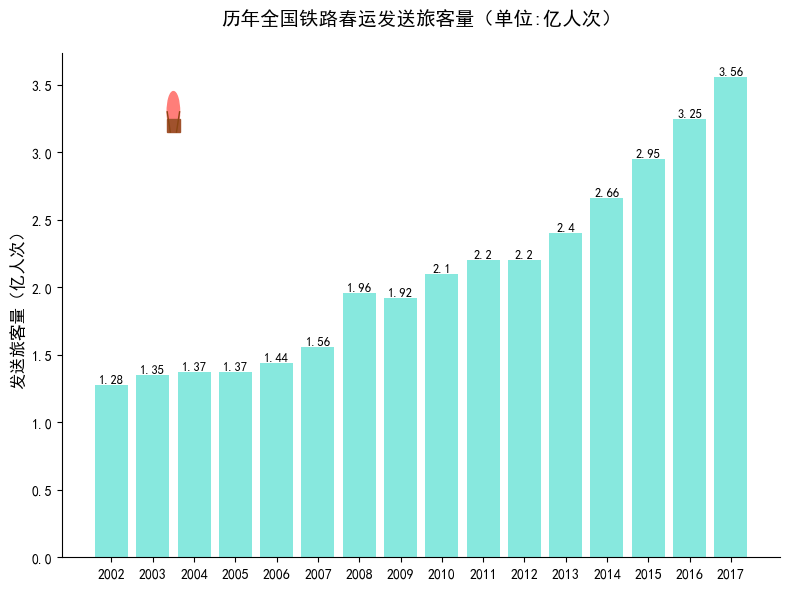

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as patches

# 年份数据
years = np.arange(2002, 2018)
# 对应年份的客运量数据（大体接近原数据）
passenger_volumes = [1.28, 1.35, 1.37, 1.37, 1.44, 1.56, 
                     1.96, 1.92, 2.1, 2.2, 2.2, 2.4, 
                     2.66, 2.95, 3.25, 3.56]

# 创建图形
fig, ax = plt.subplots(figsize=(8, 6))

# 绘制柱状图，设置颜色接近原图表的浅绿色系
bar_rects = ax.bar(years, passenger_volumes, color='#87E8DE')

# 设置 x 轴刻度
ax.set_xticks(years)
ax.set_xticklabels(years, fontsize=10)

# 设置 y 轴标签
ax.set_ylabel('发送旅客量（亿人次）', fontsize=12)
# 设置标题
ax.set_title('历年全国铁路春运发送旅客量（单位:亿人次）', fontsize=14, pad=20)

# 隐藏顶部和右侧边框
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 在柱子上标注数值
for rect in bar_rects:
    height = rect.get_height()
    ax.text(rect.get_x() + rect.get_width() / 2, height, f'{height}',
            ha='center', va='bottom', fontsize=9)

# 增加一些装饰元素，使用纯图形替代图片
hot_air_balloon = patches.Circle((2003.5, 3.3), 0.15, color='#FF7E79')
ax.add_patch(hot_air_balloon)

# 绘制热气球的篮子和绳子
basket = patches.Rectangle((2003.35, 3.15), 0.3, 0.1, color='#A0522D')
ax.add_patch(basket)

# 绘制绳子
ax.plot([2003.35, 2003.425], [3.3, 3.15], color='#8B4513', linewidth=1)
ax.plot([2003.65, 2003.575], [3.3, 3.15], color='#8B4513', linewidth=1)

plt.tight_layout()
plt.show()

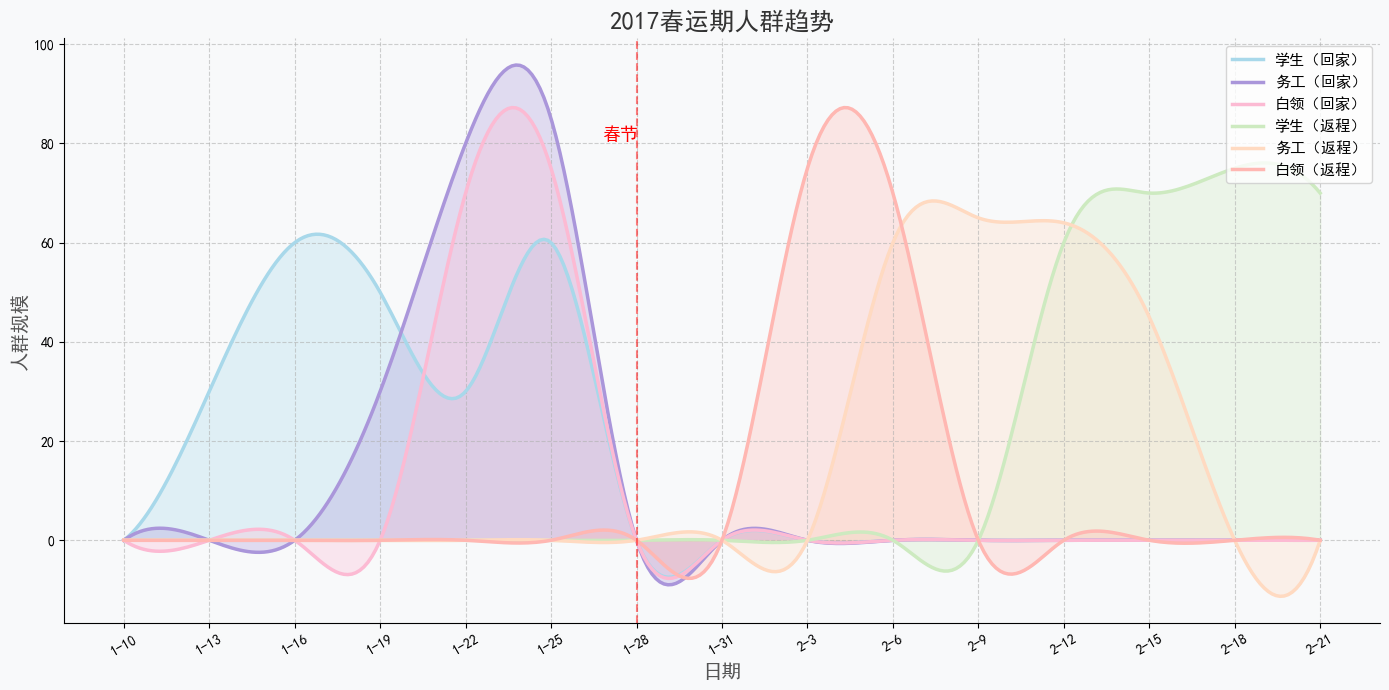

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import make_interp_spline  

# 1. 模拟原始数据（日期、人群规模）
dates = np.array(['1-10', '1-13', '1-16', '1-19', '1-22', '1-25', '1-28', 
                  '1-31', '2-3', '2-6', '2-9', '2-12', '2-15', '2-18', '2-21'])  

# 学生回家数据（峰值在1-19和1-25，1-22为峰值一半，1-10和2-21为0）
student_go = np.array([0, 30, 60, 50, 30, 60, 0, 0, 0, 0, 0, 0, 0, 0, 0])  

# 务工人员回家数据（峰值在1-25附近）
worker_go = np.array([0, 0, 0, 30, 80, 85, 0, 0, 0, 0, 0, 0, 0, 0, 0])  

# 白领回家数据（峰值在1-22附近）
white_collar_go = np.array([0, 0, 0, 0, 70, 75, 0, 0, 0, 0, 0, 0, 0, 0, 0])  

# 返程数据（均匀分布在2月）
student_back = np.array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 60, 70, 75, 70])  
worker_back = np.array([0, 0, 0, 0, 0, 0, 0, 0, 0, 60, 65, 64, 45, 0, 0])  
white_collar_back = np.array([0, 0, 0, 0, 0, 0, 0, 0, 75, 70, 0, 0, 0, 0, 0])  

# 2. 创建均匀分布的时间轴
x_uniform = np.arange(len(dates))  # 均匀分布的数值轴

# 3. 插值平滑处理
def smooth_curve(y):  
    x_new = np.linspace(x_uniform.min(), x_uniform.max(), 300)  
    spline = make_interp_spline(x_uniform, y, k=3)  
    return x_new, spline(x_new)

# 平滑处理
x_smooth, student_go_smooth = smooth_curve(student_go)
_, worker_go_smooth = smooth_curve(worker_go)
_, white_collar_go_smooth = smooth_curve(white_collar_go)

_, student_back_smooth = smooth_curve(student_back)
_, worker_back_smooth = smooth_curve(worker_back)
_, white_collar_back_smooth = smooth_curve(white_collar_back)

# 4. 绘制曲线图
fig, ax = plt.subplots(figsize=(14, 7), facecolor='#f8f9fa')
ax.set_facecolor('#f8f9fa')

# 回家阶段曲线及填充
student_go_line, = ax.plot(x_smooth, student_go_smooth, color='#A8D8EA', linewidth=2.5, label='学生（回家）')
ax.fill_between(x_smooth, student_go_smooth, color='#A8D8EA', alpha=0.3)  # 填充学生回家曲线

worker_go_line, = ax.plot(x_smooth, worker_go_smooth, color='#AA96DA', linewidth=2.5, label='务工（回家）')
ax.fill_between(x_smooth, worker_go_smooth, color='#AA96DA', alpha=0.3)  # 填充务工回家曲线

white_collar_go_line, = ax.plot(x_smooth, white_collar_go_smooth, color='#FCBAD3', linewidth=2.5, label='白领（回家）')
ax.fill_between(x_smooth, white_collar_go_smooth, color='#FCBAD3', alpha=0.3)  # 填充白领回家曲线

# 返程阶段曲线及填充
student_back_line, = ax.plot(x_smooth, student_back_smooth, color='#CDEAC0', linewidth=2.5, label='学生（返程）')
ax.fill_between(x_smooth, student_back_smooth, color='#CDEAC0', alpha=0.3)  # 填充学生返程曲线

worker_back_line, = ax.plot(x_smooth, worker_back_smooth, color='#FFDAC1', linewidth=2.5, label='务工（返程）')
ax.fill_between(x_smooth, worker_back_smooth, color='#FFDAC1', alpha=0.3)  # 填充务工返程曲线

white_collar_back_line, = ax.plot(x_smooth, white_collar_back_smooth, color='#FFB7B2', linewidth=2.5, label='白领（返程）')
ax.fill_between(x_smooth, white_collar_back_smooth, color='#FFB7B2', alpha=0.3)  # 填充白领返程曲线

# 5. 设置x轴刻度
plt.xticks(x_uniform, dates)
plt.xticks(rotation=30)  

# 6. 添加标题、图例、装饰
ax.set_title('2017春运期人群趋势', fontsize=18, fontweight='bold', color='#333')
ax.set_xlabel('日期', fontsize=14, color='#555')
ax.set_ylabel('人群规模', fontsize=14, color='#555')
ax.legend(loc='upper right', fontsize=11)  

# 7. 添加分隔线（春节位置）
plt.axvline(x=6.0, color='red', linestyle='--', alpha=0.5)
plt.text(5.6, max(student_go.max(), worker_go.max(), white_collar_go.max()) * 0.95, 
         '春节', fontsize=13, color='red')

# 8. 添加网格线
plt.grid(True, linestyle='--', alpha=0.6)

# 9. 隐藏顶部、右侧边框
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 10. 显示图表
plt.tight_layout()  
plt.show()

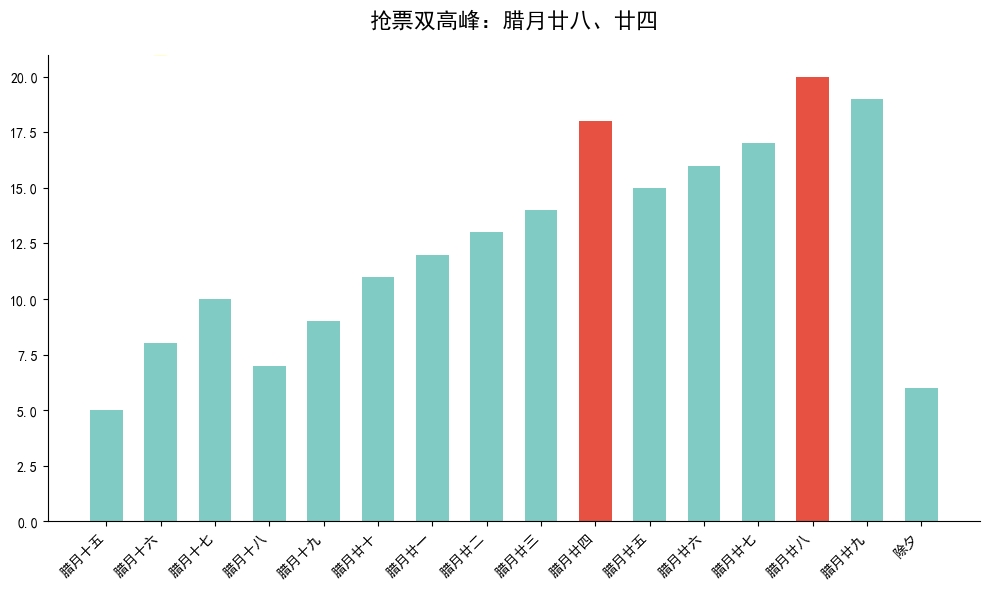

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# 日期标签
labels = ["腊月十五", "腊月十六", "腊月十七", "腊月十八", "腊月十九", "腊月廿十",
          "腊月廿一", "腊月廿二", "腊月廿三", "腊月廿四", "腊月廿五", "腊月廿六",
          "腊月廿七", "腊月廿八", "腊月廿九", "除夕"]
# 模拟的数据，大体体现高峰趋势，可根据实际微调
data = [5, 8, 10, 7, 9, 11, 12, 13, 14, 18, 15, 16, 17, 20, 19, 6]
# 标记高峰日期的索引（腊月廿四、腊月廿八 ，对应上面 labels 中的索引 9 和 13 ）
peak_indices = [9, 13]

x = np.arange(len(labels))  # x 轴位置
width = 0.6  # 柱状图宽度

fig, ax = plt.subplots(figsize=(10, 6))  # 创建画布和轴
# 绘制柱状图，大部分为一种颜色，高峰柱子用另一种颜色
bars = []
for i in range(len(x)):
    if i in peak_indices:
        bar = ax.bar(x[i], data[i], width, color='#e65142')  # 高峰颜色，近似原图表红色
    else:
        bar = ax.bar(x[i], data[i], width, color='#80cbc4')  # 其他柱子颜色，近似原图表青绿色
    bars.append(bar)

# 设置 x 轴刻度和标签
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha='right')

# 设置标题
ax.set_title('抢票双高峰：腊月廿八、廿四', fontsize=16, pad=20)

# 隐藏顶部和右侧边框
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 添加一些装饰元素，模拟原图表的小太阳、云朵（简单示意，可根据需求细化）
import matplotlib.patches as patches
# 画小太阳
sun = patches.Circle((1, max(data) + 2), radius=1, color='yellow', alpha=0.8)
ax.add_patch(sun)
# 画云朵（简单矩形模拟，可更精细绘制）
cloud1 = patches.Rectangle((3, max(data) + 1.5), 2, 1, color='white', alpha=0.8)
cloud2 = patches.Rectangle((6, max(data) + 1), 2, 1, color='white', alpha=0.8)
ax.add_patch(cloud1)
ax.add_patch(cloud2)

plt.tight_layout()  # 自动调整布局
plt.show()

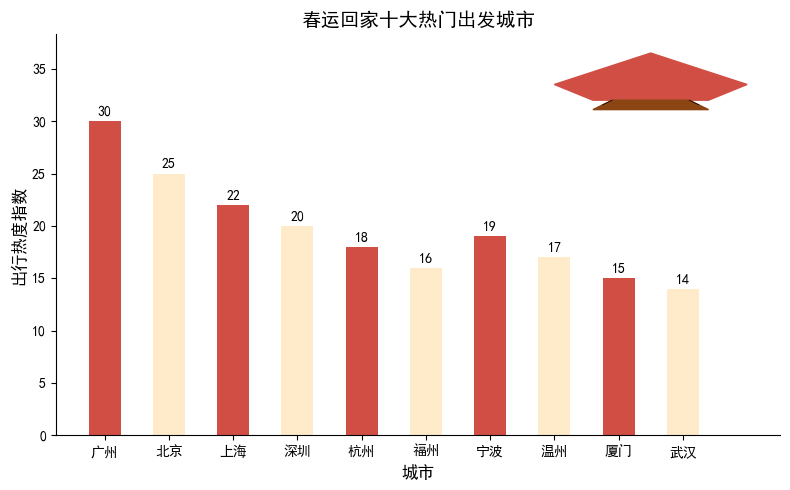

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# 城市名称
cities = ["广州", "北京", "上海", "深圳", "杭州", "福州", "宁波", "温州", "厦门", "武汉"]
# 模拟的柱状图数据，大体体现高度差异，可根据实际微调
data = [30, 25, 22, 20, 18, 16, 19, 17, 15, 14]

x = np.arange(len(cities))  # x轴坐标
width = 0.5  # 柱子宽度

fig, ax = plt.subplots(figsize=(8, 5))  # 创建画布和轴对象，设置图尺寸
# 绘制柱状图，颜色设置为接近原图的两种色调，可微调rgb值更贴近
bars1 = ax.bar(x[::2], data[::2], width, color=(209/255, 78/255, 68/255))  # 红色系柱子
bars2 = ax.bar(x[1::2], data[1::2], width, color=(255/255, 235/255, 201/255))  # 浅米色柱子

# 设置x轴刻度和标签
ax.set_xticks(x)
ax.set_xticklabels(cities)
# 设置图表标题
ax.set_title("春运回家十大热门出发城市", fontsize=14, fontweight='bold')

# 添加x轴标签
ax.set_xlabel("城市", fontsize=12)
# 添加y轴标签和单位
ax.set_ylabel("出行热度指数", fontsize=12)

# 隐藏上、右坐标轴
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 在每个柱子上方添加数值标签
for i, v in enumerate(data):
    ax.text(i, v + 0.5, str(v), ha='center', fontsize=10)

# 使用纯绘图方式创建装饰元素，替代图片
from matplotlib.patches import Polygon, Circle

# 创建热气球形状
def create_balloon(ax, x, y, scale=1.0):
    # 气球主体
    balloon = Polygon([
        (x, y+15*scale), (x-5*scale, y+5*scale), (x-3*scale, y), 
        (x+3*scale, y), (x+5*scale, y+5*scale), (x, y+15*scale)
    ], fill=True, color=(209/255, 78/255, 68/255))
    ax.add_patch(balloon)
    
    # 吊篮
    basket = Polygon([
        (x-2*scale, y), (x-3*scale, y-3*scale), 
        (x+3*scale, y-3*scale), (x+2*scale, y)
    ], fill=True, color=(139/255, 69/255, 19/255))
    ax.add_patch(basket)
    
    # 绳子
    ax.plot([x-2*scale, x-2.5*scale], [y, y-1.5*scale], 'k-', linewidth=0.5)
    ax.plot([x+2*scale, x+2.5*scale], [y, y-1.5*scale], 'k-', linewidth=0.5)

# 在右上角添加热气球装饰
create_balloon(ax, 8.5, 32, scale=0.3)

plt.tight_layout()  # 调整布局，确保标签不被遮挡
plt.show()

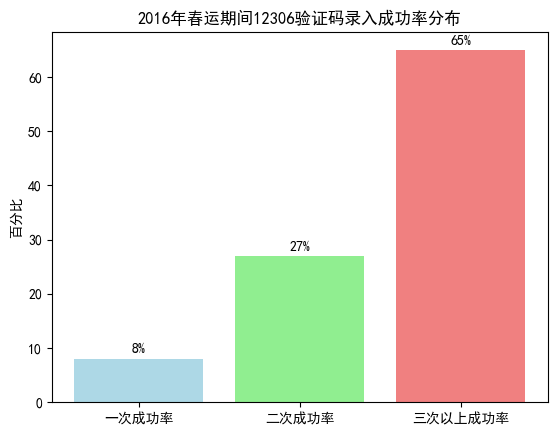

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# 数据
labels = ['一次成功率', '二次成功率', '三次以上成功率']
values = [8, 27, 65]

# 创建图形
fig, ax = plt.subplots()

# 绘制柱状图
ax.bar(labels, values, color=['lightblue', 'lightgreen', 'lightcoral'])

# 添加数值标签
for i, v in enumerate(values):
    ax.text(i, v + 1, f'{v}%', ha='center')

# 设置标题和坐标轴标签（可根据需求调整）
ax.set_ylabel('百分比')
# 添加标题
ax.set_title('2016年春运期间12306验证码录入成功率分布')

# 显示图形
plt.show()